<a href="https://colab.research.google.com/github/huseyinTozluyurt/Machine-Learning-Projects/blob/main/BeginnerProjects/CancerDataset/CancerDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Load Cancer Dataset

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

print(cancer.DESCR) # Print the data set description

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [2]:
cancer_dataset = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
display(cancer_dataset.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [5]:
cancer.filename

'breast_cancer.csv'

In [6]:
features = cancer.feature_names

In [7]:
features.shape[0]

30

In [8]:
cancer.target.shape

(569,)

In [9]:
size=cancer.target.shape
size[0]

569

## Calculating Malignant and Benign in the Dataset

In [10]:
size = cancer.target.shape[0]
malignant_count=0
benign_count=0
invalid_count=0
for i in range(size):
  if cancer.target[i]==0:
    malignant_count += 1
  elif cancer.target[i]==1:
    benign_count += 1
  else:
    invalid_count += 1
print("malignant_count: ",malignant_count)
print("benign_count: ",benign_count)
print("invalid_count: ",invalid_count)

malignant_count:  212
benign_count:  357
invalid_count:  0


## Splitting the Dataset

In [11]:
cancer_dataset.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
features = cancer_dataset.columns
features.shape

(30,)

In [13]:
dataset_shape = cancer_dataset.shape
dataset_shape

(569, 30)

In [14]:
cancer.target.shape

(569,)

In [15]:
X = cancer_dataset
y = cancer.target


In [16]:
def split_data():
    X = cancer_dataset
    y = cancer.target
    return (X, y)

In [17]:
X, y = split_data()
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (569, 30)
Shape of y: (569,)


## Train-Test-Split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Print the shapes of the resulting datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (426, 30)
Shape of X_test: (143, 30)
Shape of y_train: (426,)
Shape of y_test: (143,)


## Fitting the Model

In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 1)

In [33]:
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=1)

In [28]:
data_shaped = cancer_dataset.mean().values.reshape(1, -1)

In [29]:
data_shaped = pd.DataFrame(data=data_shaped, columns=cancer.feature_names)

In [30]:
prediction = knn.predict(data_shaped)
print(f"The prediction for the new data point is: {prediction}")

The prediction for the new data point is: [1]


In [35]:
my_knn_test_score = knn.score(X_test, y_test)
print(f"Test Set Score: {my_knn_test_score}")

Test Set Score: 0.916083916083916


In [36]:
my_knn_train_score = knn.score(X_train, y_train)
print(f"Training Set Score: {my_knn_train_score}")

Training Set Score: 1.0


## Visualizing Results

The `plot_knn_decision_boundary` function expects 2 features for visualization. Since our dataset has 30 features, we need to reduce its dimensionality. We can use Principal Component Analysis (PCA) to reduce the features to 2 principal components for plotting.

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_train_pca_df = pd.DataFrame(data = X_train_pca, columns = ['principal component 1', 'principal component 2'])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


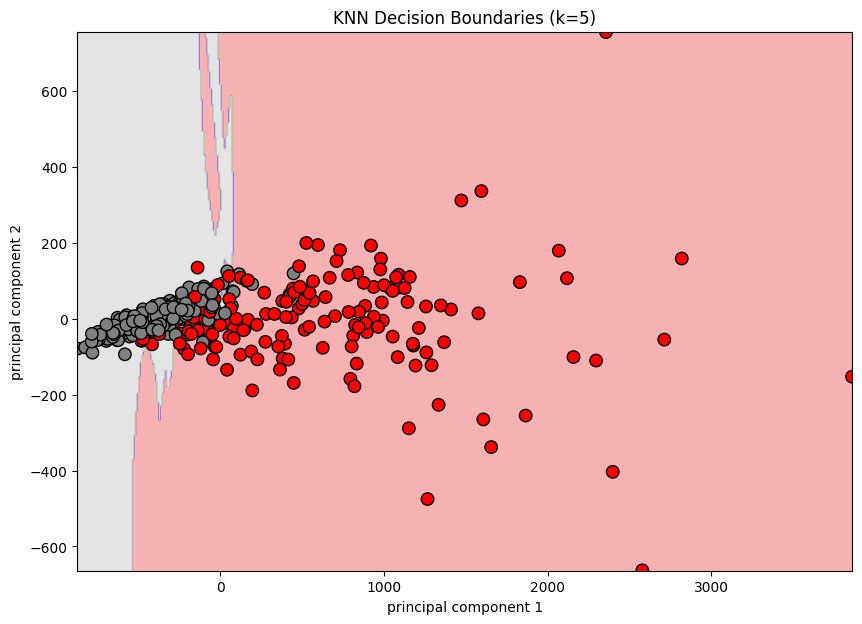

In [43]:
# Now, call the plotting function with the PCA-transformed data
# We need to pass y_train as a Series with an index to match X_train_pca_df for consistency in plotting function
plot_knn_decision_boundary(
    X_train_pca_df,
    pd.Series(y_train, index=X_train_pca_df.index),
    k=5
)